# 01 — Intuição do transformer: atenção, Q/K/V e máscara causal

> Destilado da **seção 2 do projeto** (Fundamentos teóricos do transformer) e do
> capítulo 5 do 3Blue1Brown. É a base conceitual de
> `src/tucanoce/model/layers/attention.py` e `src/tucanoce/model/block.py`.

No notebook 00 vimos que uma rede é `W·a+b` + não-linearidade, treinada por
gradiente. Aqui montamos a peça que define o transformer: a **atenção**, o
mecanismo que move informação entre posições de uma sequência. Tudo com tensores
pequenos que rodam, e cada afirmação conferida contra o PyTorch.

**O que você vai sair sabendo:**
1. O que um LM autoregressivo calcula: $p(x_{t+1}\mid x_1,\dots,x_t)$.
2. Por que embeddings viram "direções semânticas" e o papel do produto interno.
3. Atenção como média ponderada, e de onde vem a matriz de pesos $A$ (Q/K/V).
4. Por que a máscara causal existe e como ela é implementada.
5. Multi-head, MLP, conexões residuais — o bloco completo.
6. Logits, softmax e temperatura na amostragem.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Convenção visual do projeto (mesma do nb 00).
plt.rcParams.update({
    "figure.figsize": (6, 4), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})
torch.manual_seed(0); np.random.seed(0)
print("torch", torch.__version__)

torch 2.12.1+cpu


## 1. O objetivo: prever o próximo token

GPT = *Generative Pretrained Transformer*. O pré-treino resolve **uma** tarefa:
dado um prefixo de tokens $x_1,\dots,x_t$, atribuir uma distribuição de
probabilidade sobre qual token vem a seguir:

$$ p_\theta(x_{t+1}\mid x_1,\dots,x_t). $$

Gerar texto é um **loop**: amostrar $x_{t+1}$ dessa distribuição, concatenar ao
prefixo, repetir. Parece estranho que "prever a próxima palavra" produza texto
coerente — mas é exatamente isso que um LM faz, e a coerência emerge da **escala**
(nb 01 do projeto; o próprio Sanderson nota que GPT-2 num laptop mal faz sentido,
e trocar só a escala para GPT-3 muda o resultado).

In [2]:
# Esqueleto do loop de geração (com um "modelo" falso que só devolve logits aleatórios).
# O ponto é a MECÂNICA: prever -> amostrar -> concatenar -> repetir.
vocab = ["<bos>", "the", "electron", "has", "charge", "mass", "."]
V = len(vocab)

def fake_model(prefix_ids):          # devolve logits do "próximo token"
    torch.manual_seed(sum(prefix_ids))
    return torch.randn(V)

seq = [0]                            # começa com <bos>
for _ in range(5):
    logits = fake_model(seq)
    probs = F.softmax(logits, dim=-1)
    nxt = torch.multinomial(probs, 1).item()   # amostra
    seq.append(nxt)
print("ids gerados:", seq)
print("texto      :", " ".join(vocab[i] for i in seq))
print("\n(o modelo é aleatório; o que importa é o LOOP, não a qualidade)")

ids gerados: [0, 3, 2, 5, 4, 5]
texto      : <bos> has electron mass charge mass

(o modelo é aleatório; o que importa é o LOOP, não a qualidade)


## 2. Tokens, embeddings e direções semânticas

O primeiro passo quebra o texto em **tokens** (notebook 02) e mapeia cada um para
um vetor de dimensão $d$, sua **embedding**. A matriz $W_e \in \mathbb{R}^{V\times d}$
tem uma linha por token — é uma busca em tabela.

A ideia central: **direções** nesse espaço carregam significado. O exemplo
clássico é `king - man + woman ≈ queen`. A ferramenta para medir alinhamento entre
direções é o **produto interno**:

$$ \mathbf{u}\cdot\mathbf{v} = \lVert\mathbf{u}\rVert\,\lVert\mathbf{v}\rVert\cos\theta $$

positivo quando apontam no mesmo sentido, zero quando perpendiculares. Que a
computação interna do transformer seja produto interno **não é coincidência** —
é a operação que a arquitetura precisa que predomine (nb 01).

In [3]:
# Espaço-brinquedo montado à MÃO para ver "direção = significado".
# 2 eixos interpretáveis: eixo 0 = "realeza", eixo 1 = "feminino".
emb = {
    "man":   np.array([0.2, 0.0]),
    "woman": np.array([0.2, 1.0]),
    "king":  np.array([1.0, 0.0]),
    "queen": np.array([1.0, 1.0]),
}
# A direção "man->woman" deve ser ~ a direção "king->queen" (ambas = +feminino).
d_gender_1 = emb["woman"] - emb["man"]
d_gender_2 = emb["queen"] - emb["king"]
print("woman-man :", d_gender_1)
print("queen-king:", d_gender_2, "  (mesma direção => mesmo 'significado' de gênero)")

# Analogia: king - man + woman  ~=  queen
pred = emb["king"] - emb["man"] + emb["woman"]
print("\nking-man+woman =", pred, " | queen =", emb["queen"])
print("bate?", np.allclose(pred, emb["queen"]))

woman-man : [0. 1.]
queen-king: [0. 1.]   (mesma direção => mesmo 'significado' de gênero)

king-man+woman = [1. 1.]  | queen = [1. 1.]
bate? True


In [4]:
# Produto interno como medida de alinhamento (cosseno).
def cos(u, v): return float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))
print("cos(king, queen) =", round(cos(emb['king'], emb['queen']), 3), " (alinhados)")
print("cos(man,  woman) =", round(cos(emb['man'],  emb['woman']), 3))
print("cos(d_gender_1, d_gender_2) =", round(cos(d_gender_1, d_gender_2), 3),
      " (as duas direções de gênero são idênticas => cos=1)")

cos(king, queen) = 0.707  (alinhados)
cos(man,  woman) = 0.196
cos(d_gender_1, d_gender_2) = 1.0  (as duas direções de gênero são idênticas => cos=1)


**O que observar:** as quatro palavras nos dois eixos interpretáveis (realeza ×
feminino). A seta pontilhada é `king − man + woman`: ela aterrissa exatamente sobre
`queen`. "Somar uma direção" no espaço de embeddings = somar significado.

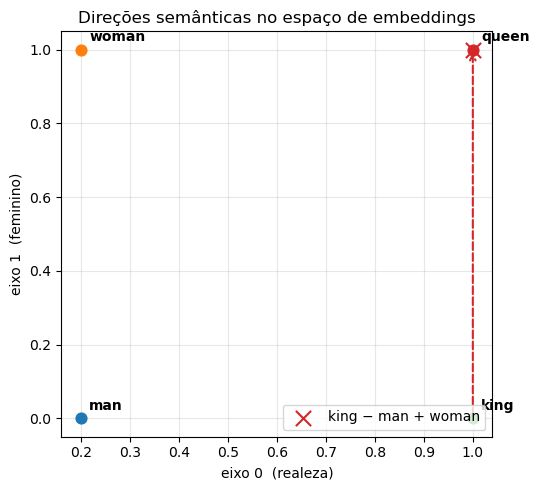

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for w, v in emb.items():
    ax.scatter(*v, s=60, zorder=3)
    ax.annotate(w, v, textcoords="offset points", xytext=(6, 6), fontweight="bold")
# vetor da analogia king - man + woman
ax.annotate("", xy=pred, xytext=emb["king"],
            arrowprops=dict(arrowstyle="->", ls="--", color="C3", lw=1.5))
ax.scatter(*pred, marker="x", s=120, color="C3", zorder=4,
           label="king − man + woman")
ax.set_xlabel("eixo 0  (realeza)"); ax.set_ylabel("eixo 1  (feminino)")
ax.set_title("Direções semânticas no espaço de embeddings")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

Um detalhe que motiva a atenção: nesse primeiro passo a embedding é
**independente de contexto**. O token `mole` recebe o mesmo vetor em "American
shrew mole", "mole of carbon" e "biopsy of the mole" — a tabela não olha os
vizinhos. O trabalho da rede, camada após camada, é **empurrar** esse vetor
genérico para uma direção que codifique o sentido *naquele* contexto. Quem faz
esse empurrão é a atenção.

## 3. A forma dos dados e o bloco

Empilhando as $T$ embeddings do contexto obtemos uma matriz

$$ X^{(0)} \in \mathbb{R}^{T\times d}, $$

uma linha por token, uma coluna por feature. O transformer aplica repetidamente
um mesmo **bloco**:

$$ X^{(m)} = \mathrm{bloco}\big(X^{(m-1)}\big),\quad m=1,\dots,L. $$

Cada bloco tem dois estágios com papéis distintos:
- **Atenção** age *através da sequência* — deixa os tokens trocarem informação.
- **MLP** age *através das features* — refina cada token isoladamente.

Essa alternância (misturar posições, depois misturar features) é o esqueleto da
arquitetura. Usamos a convenção *batch-first* $T\times d$ do PyTorch (o projeto de
Turner transpõe, mas descreve a mesma operação).

## 4. Atenção como média ponderada

A operação básica é simples: a saída na posição $t$ é uma **média ponderada** das
features de entrada em todas as posições,

$$ \mathbf{y}_t = \sum_{t'=1}^{T} A_{t,t'}\,\mathbf{x}_{t'},\qquad \sum_{t'} A_{t,t'}=1. $$

Em forma matricial, $Y = A X$. A matriz $A \in \mathbb{R}^{T\times T}$ é a
**matriz de atenção**: $A_{t,t'}$ é o quanto a posição $t$ "presta atenção" à
posição $t'$. Toda a questão vira: **de onde vem $A$?**

In [6]:
# Média ponderada com uma matriz A fixa (inventada), só pra ver a mecânica.
T, d = 4, 8
X = torch.randn(T, d)
A = torch.tensor([[1.0, 0, 0, 0],       # pos 0 só olha pra si
                  [0.5, 0.5, 0, 0],     # pos 1 média de 0 e 1
                  [0.3, 0.3, 0.4, 0],
                  [0.1, 0.2, 0.3, 0.4]])
Y = A @ X
print("linhas de A somam 1?", torch.allclose(A.sum(-1), torch.ones(T)))
print("Y shape:", tuple(Y.shape), "(= T x d, mesma forma de X)")
# a saída da pos 1 é exatamente a média de X[0] e X[1]:
print("Y[1] == média(X[0],X[1])?", torch.allclose(Y[1], (X[0]+X[1])/2))

linhas de A somam 1? True
Y shape: (4, 8) (= T x d, mesma forma de X)
Y[1] == média(X[0],X[1])? True


## 5. Self-attention: de onde vem $A$ (Q e K)

A ideia que dá nome ao mecanismo: gerar $A$ **a partir da própria sequência**. A
versão ingênua mede similaridade pelo produto interno entre embeddings e
normaliza com softmax. Mas isso tem dois problemas: mistura similaridade de
posição com conteúdo bruto, e é **simétrica** (não consegue expressar que "A se
associa fortemente a B" enquanto "B se associa fracamente a A").

A solução: projetar cada embedding por **duas** matrizes aprendidas distintas:

$$ \mathbf{q}_t = \mathbf{x}_t W_Q,\qquad \mathbf{k}_t = \mathbf{x}_t W_K $$

a **query** ("o que estou procurando") e a **key** ("o que eu ofereço"). O
alinhamento query–key dá a similaridade:

$$ A_{t,t'} = \mathrm{softmax}_{t'}\!\left(\frac{\mathbf{q}_t\cdot\mathbf{k}_{t'}}{\sqrt{d_h}}\right). $$

A divisão por $\sqrt{d_h}$ estabiliza numericamente o produto interno antes do
softmax (variância cresce com $d_h$).

In [7]:
T, d, d_h = 4, 8, 4
X = torch.randn(T, d)
W_Q = torch.randn(d, d_h) * 0.5
W_K = torch.randn(d, d_h) * 0.5

Q = X @ W_Q                       # (T, d_h)
K = X @ W_K                       # (T, d_h)
scores = (Q @ K.T) / (d_h ** 0.5) # (T, T)  produto interno query-key escalado
A = F.softmax(scores, dim=-1)     # softmax por linha
print("scores (bruto):\n", scores.round(decimals=2))
print("\nA (após softmax):\n", A.round(decimals=3))
print("\nlinhas de A somam 1?", torch.allclose(A.sum(-1), torch.ones(T), atol=1e-6))
print("A é assimétrica? A[0,1] != A[1,0]:", not torch.allclose(A[0,1], A[1,0]))

scores (bruto):
 tensor([[-1.6800,  0.4400,  0.4200, -1.5100],
        [ 0.8500,  1.0200, -0.2700,  2.0500],
        [ 0.5500,  0.0900, -0.6500, -1.1400],
        [-1.2400,  1.1200, -0.8500, -4.5200]])

A (após softmax):
 tensor([[0.0540, 0.4460, 0.4370, 0.0630],
        [0.1710, 0.2030, 0.0560, 0.5700],
        [0.4730, 0.2980, 0.1420, 0.0870],
        [0.0760, 0.8090, 0.1130, 0.0030]])

linhas de A somam 1? True
A é assimétrica? A[0,1] != A[1,0]: True


## 6. A máscara causal

Num modelo autoregressivo, a posição $t$ **não pode** atender a posições futuras
$t' > t$ — senão a resposta vazaria durante o treino. Isso importa porque o treino
é eficiente: numa única passada, o modelo prevê o próximo token para *cada*
prefixo, e uma sequência vira muitos exemplos de treino ao mesmo tempo.

Zerar as entradas futuras direto quebraria a normalização do softmax (as linhas
não somariam 1). A solução é somar $-\infty$ nessas entradas **antes** do softmax:
$e^{-\infty}=0$, então elas viram exatamente zero *depois*, e a linha continua
somando 1.

In [8]:
# Máscara triangular: -inf acima da diagonal (posições futuras).
mask = torch.triu(torch.full((T, T), float('-inf')), diagonal=1)
print("máscara (somada aos scores):\n", mask)

scores_masked = scores + mask
A_causal = F.softmax(scores_masked, dim=-1)
print("\nA causal (triangular inferior):\n", A_causal.round(decimals=3))
print("\nentradas futuras são exatamente 0?",
      torch.all(A_causal.triu(1) == 0).item())
print("linhas ainda somam 1?", torch.allclose(A_causal.sum(-1), torch.ones(T), atol=1e-6))

máscara (somada aos scores):
 tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])

A causal (triangular inferior):
 tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4570, 0.5430, 0.0000, 0.0000],
        [0.5180, 0.3270, 0.1550, 0.0000],
        [0.0760, 0.8090, 0.1130, 0.0030]])

entradas futuras são exatamente 0? True
linhas ainda somam 1? True


**O que observar:** a mesma matriz de atenção $A$ sem e com a máscara causal. À
esquerda, toda posição olha todas (inclusive o futuro). À direita, o triângulo
superior zera: a query $t$ (linha) só enxerga keys $t'\le t$ (coluna). Cada linha
continua somando 1 — é uma distribuição de probabilidade sobre as posições visíveis.

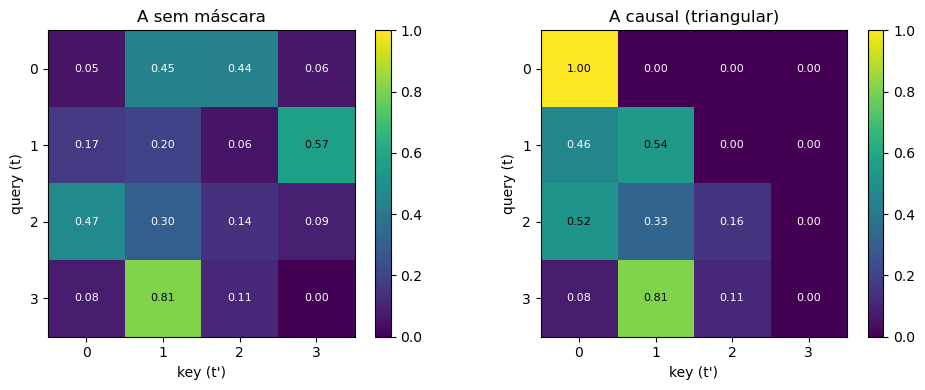

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, M, ttl in [(axes[0], A, "A sem máscara"),
                   (axes[1], A_causal, "A causal (triangular)")]:
    im = ax.imshow(M.detach(), cmap="viridis", vmin=0, vmax=1)
    ax.set_xlabel("key (t')"); ax.set_ylabel("query (t)"); ax.set_title(ttl)
    ax.set_xticks(range(T)); ax.set_yticks(range(T)); ax.grid(False)
    for i in range(T):                      # anota o peso em cada célula
        for j in range(T):
            v = M[i, j].item()
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v < 0.5 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

Note que $A$ é $T\times T$: o custo é **quadrático** no contexto. É o gargalo que
motiva Flash Attention (evita materializar essa matriz na memória) e as janelas de
contexto limitadas — voltamos a isso no notebook 04.

## 7. Values: o que efetivamente é somado

$A$ diz *quem* é relevante para *quem*; falta dizer *o que* mover. Uma terceira
matriz aprendida produz o **value** de cada token, $\mathbf{v}_{t'} = \mathbf{x}_{t'} W_V$
— o vetor que aquela posição contribui caso seja relevante. A atualização da
posição $t$ é a média ponderada dos values:

$$ \Delta\mathbf{x}_t = \sum_{t'} A_{t,t'}\,\mathbf{v}_{t'}, \qquad \text{um head} = A\,(X W_V). $$

Esse resultado é **somado de volta** à embedding (a conexão residual da seção 9).

In [10]:
W_V = torch.randn(d, d_h) * 0.5
Vv = X @ W_V                      # (T, d_h)
head_out = A_causal @ Vv         # (T, d_h)  saída de UM head de atenção
print("head_out shape:", tuple(head_out.shape))
# a saída da pos 0 (que só se vê) é exatamente o value dela:
print("head_out[0] == V[0]?", torch.allclose(head_out[0], Vv[0], atol=1e-6))

head_out shape: (4, 4)
head_out[0] == V[0]? True


## 8. Multi-head: vários padrões em paralelo

Uma única matriz de atenção é um gargalo: gostaríamos que dois tokens fossem
parecidos em algumas "dimensões" e diferentes em outras. A solução é rodar $H$
**cabeças** em paralelo, cada uma com seu próprio $W_Q, W_K, W_V$ e seu próprio
padrão de atenção. Concatenam-se as saídas e projeta-se de volta por $W_O$:

$$ \mathrm{MHSA}(X) = \mathrm{Concat}(\text{head}_1,\dots,\text{head}_H)\,W_O. $$

Cada cabeça aprende uma forma distinta pela qual o contexto altera significado
(adjetivo→substantivo numa, sujeito→verbo noutra, referência de longo alcance
noutra). GPT-3 usa 96 cabeças por bloco.

Vamos implementar multi-head à mão e **conferir** contra
`F.scaled_dot_product_attention` do PyTorch (que chama Flash Attention quando dá),
usando exatamente os mesmos pesos.

In [11]:
torch.manual_seed(1)
T, d, H = 5, 12, 3
d_h = d // H                       # dimensão por cabeça = 4
X = torch.randn(1, T, d)           # (batch=1, T, d)

# Projeções combinadas (todas as cabeças de uma vez), sem bias — estilo do projeto.
W_Q = nn.Linear(d, d, bias=False)
W_K = nn.Linear(d, d, bias=False)
W_V = nn.Linear(d, d, bias=False)
W_O = nn.Linear(d, d, bias=False)

def split_heads(x):                # (1,T,d) -> (1,H,T,d_h)
    return x.view(1, T, H, d_h).transpose(1, 2)

Q = split_heads(W_Q(X)); K = split_heads(W_K(X)); Vv = split_heads(W_V(X))

# ---- multi-head À MÃO ----
scores = (Q @ K.transpose(-2, -1)) / (d_h ** 0.5)      # (1,H,T,T)
causal = torch.triu(torch.full((T, T), float('-inf')), 1)
A = F.softmax(scores + causal, dim=-1)
ctx = A @ Vv                                            # (1,H,T,d_h)
ctx = ctx.transpose(1, 2).contiguous().view(1, T, d)   # concat das cabeças
out_manual = W_O(ctx)

# ---- mesma coisa via PyTorch (Flash Attention quando disponível) ----
ctx_ref = F.scaled_dot_product_attention(Q, K, Vv, is_causal=True)
out_ref = W_O(ctx_ref.transpose(1, 2).contiguous().view(1, T, d))

print("out shape:", tuple(out_manual.shape))
print("à mão == F.scaled_dot_product_attention?",
      torch.allclose(out_manual, out_ref, atol=1e-5))

out shape: (1, 5, 12)
à mão == F.scaled_dot_product_attention? True


Bate. É por isso que `attention.py` usa `F.scaled_dot_product_attention`: é a nossa
implementação à mão, só que com kernel otimizado (Flash Attention) que não
materializa a matriz $T\times T$ na VRAM.

## 9. MLP, conexões residuais e o bloco completo

O segundo estágio do bloco aplica uma **MLP** à feature de cada posição, com os
*mesmos* pesos em toda posição. Diferente da atenção, aqui os tokens **não**
conversam: cada vetor passa pela mesma transformação não-linear isoladamente. É
onde mora a maioria dos parâmetros do transformer (~2/3 em GPT-3).

Os dois estágios **corrigem** a representação em vez de substituí-la — cada um é
embrulhado numa **conexão residual**:

$$ X^{(m)} = X^{(m-1)} + \mathrm{res}\big(X^{(m-1)}\big) $$

o que equivale a modelar a *diferença* $X^{(m)}-X^{(m-1)}$. Funciona bem quando
cada estágio aplica uma transformação suave, próxima da identidade; ao longo de
muitas camadas, transformações suaves se compõem em transformações grandes e
estáveis. A **normalização** (RMSNorm, notebook 04) impede que a magnitude exploda.

In [12]:
# Bloco completo (versão base, pre-norm) num tensor pequeno.
class MLP(nn.Module):
    def __init__(self, d, mult=4):
        super().__init__()
        self.fc1 = nn.Linear(d, mult * d)
        self.fc2 = nn.Linear(mult * d, d)
    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))

norm1, norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
mlp = MLP(d)

# pre-norm: normaliza ANTES de cada sub-camada; soma residual
h = X
h = h + W_O(F.scaled_dot_product_attention(
        *[split_heads(p(norm1(h))) for p in (W_Q, W_K, W_V)], is_causal=True
    ).transpose(1, 2).contiguous().view(1, T, d))
h = h + mlp(norm2(h))
print("saída do bloco shape:", tuple(h.shape), "(inalterado: residual preserva a forma)")
print("residual manteve a magnitude sob controle? norma média:",
      round(h.norm(dim=-1).mean().item(), 2))

saída do bloco shape: (1, 5, 12) (inalterado: residual preserva a forma)
residual manteve a magnitude sob controle? norma média: 3.32


## 10. Unembedding, logits e temperatura

Depois dos $L$ blocos, a representação da última posição deveria conter tudo que
importa para a próxima palavra. Uma matriz de **unembedding** mapeia esse vetor
para um número por token do vocabulário — os **logits**:

$$ \mathbf{z} = \mathbf{x}^{(L)}_T\,W_U,\qquad W_U \in \mathbb{R}^{d\times V}. $$

No nosso modelo $W_U = W_e^\top$ (**weight tying**, notebook 03). Os logits viram
probabilidade pelo softmax com um parâmetro de **temperatura** $\tau$:

$$ p_i = \frac{\exp(z_i/\tau)}{\sum_j \exp(z_j/\tau)}. $$

$\tau\to 0$ colapsa no argmax (texto previsível, repetitivo); $\tau$ maior achata
a distribuição (mais variedade, com risco de incoerência). É o botão de
amostragem que o notebook 07 detalha (junto de top-k e top-p).

In [13]:
logits = torch.tensor([2.0, 1.0, 0.1, -0.5, -1.0])   # 5 tokens
for tau in [0.2, 1.0, 3.0]:
    p = F.softmax(logits / tau, dim=-1)
    print(f"tau={tau:>3}:  {p.round(decimals=3).tolist()}   argmax_prob={p.max():.3f}")
print("\ntau baixo -> quase argmax (afiado); tau alto -> quase uniforme (achatado)")

tau=0.2:  [0.9929999709129333, 0.007000000216066837, 0.0, 0.0, 0.0]   argmax_prob=0.993
tau=1.0:  [0.6060000061988831, 0.22300000488758087, 0.09099999815225601, 0.05000000074505806, 0.029999999329447746]   argmax_prob=0.606
tau=3.0:  [0.328000009059906, 0.23499999940395355, 0.17399999499320984, 0.1420000046491623, 0.12099999934434891]   argmax_prob=0.328

tau baixo -> quase argmax (afiado); tau alto -> quase uniforme (achatado)


**O que observar:** a MESMA distribuição de logits vista sob três temperaturas.
$\tau$ baixo (0,2) concentra quase toda a massa no token mais provável — texto
determinístico e repetitivo. $\tau$ alto (3,0) achata em direção ao uniforme —
mais diversidade, mais risco de incoerência. É o botão de amostragem do nb 07.

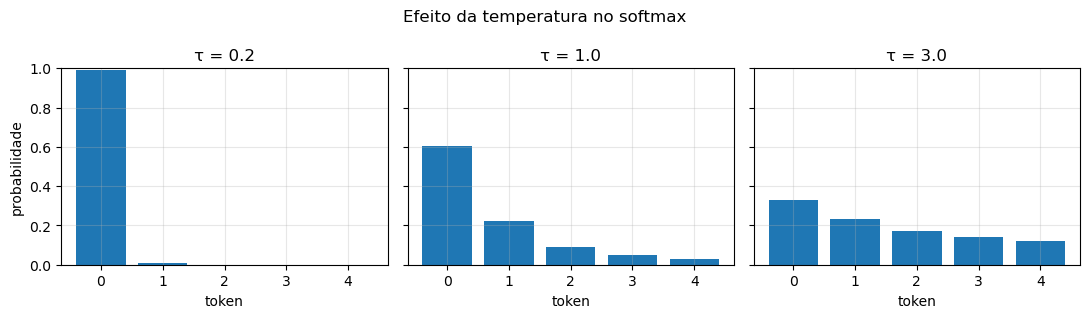

In [14]:
taus = [0.2, 1.0, 3.0]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
idx = np.arange(len(logits))
for ax, tau in zip(axes, taus):
    p = F.softmax(logits / tau, dim=-1).numpy()
    ax.bar(idx, p, color="C0")
    ax.set_title(f"τ = {tau}"); ax.set_xlabel("token"); ax.set_xticks(idx)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("probabilidade")
fig.suptitle("Efeito da temperatura no softmax")
plt.tight_layout(); plt.show()

## Resumo (o que carregar para os próximos notebooks)

| Peça | Fórmula-chave | Onde vira código |
|---|---|---|
| Objetivo | $p_\theta(x_{t+1}\mid x_{\le t})$ | loss no nb 06 |
| Embedding | busca em tabela $W_e$; direção = significado | `nn.Embedding` (nb 03) |
| Atenção | $A=\mathrm{softmax}(QK^\top/\sqrt{d_h})$, $Y=AV$ | `attention.py` (nb 03/04) |
| Máscara causal | $-\infty$ acima da diagonal antes do softmax | `is_causal=True` |
| Multi-head | $H$ padrões em paralelo + $W_O$ | `CausalSelfAttention` |
| MLP + residual | $X^{(m)}=X^{(m-1)}+\mathrm{res}(\cdot)$ | `block.py` (nb 03) |
| Logits/temperatura | softmax$(z/\tau)$ | `generate.py` (nb 07) |

**Caminho de evolução:** os capítulos 5–6 do 3Blue1Brown para a intuição visual, e
o *An Introduction to Transformers* (Turner, arXiv:2304.10557) para o formalismo
matricial completo — as duas fontes que o projeto segue nesta seção.

Próximo: **`02_tokenizacao_bpe.ipynb`** — como o texto vira os IDs que entram na
embedding.